In [1]:
import os
os.chdir('c:\\Users\\Mikael Huff\\Documents\\Training')
os.getcwd()

'c:\\Users\\Mikael Huff\\Documents\\Training'

# Basic Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Import Data

In [3]:
data = pd.read_csv('data/exNB.csv', header=None)
data

,0,1,2
0,75.626754,181.704486,1.0
1,70.540408,176.177640,1.0
2,76.875023,178.667364,1.0
3,70.225610,157.504877,1.0
4,74.106298,168.525499,1.0
...,...,...,...
995,68.394140,141.464087,0.0
996,65.280727,138.177757,0.0
997,65.345827,135.199530,0.0
998,59.385331,152.598596,0.0


In [4]:
X = data.to_numpy()
y = X[:,2]
X = X[:,:2]

## Data Visualization

In [5]:
X[y==0].shape

(500, 2)

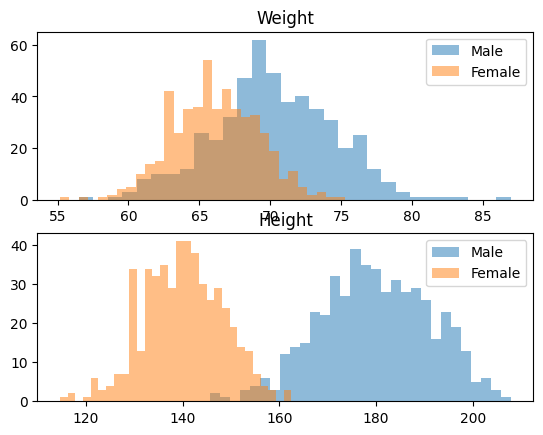

In [6]:
plt.figure()
plt.subplot(2,1,1)
plt.hist(X[y==1,0], label='Male', alpha=.5, bins=30)
plt.hist(X[y==0,0], label='Female', alpha=.5, bins=30)
plt.legend()
plt.title('Weight')
plt.subplot(2,1,2)
plt.hist(X[y==1,1], label='Male', alpha=.5, bins=30)
plt.hist(X[y==0,1], label='Female', alpha=.5, bins=30)
plt.legend()
plt.title('Height')
plt.show()

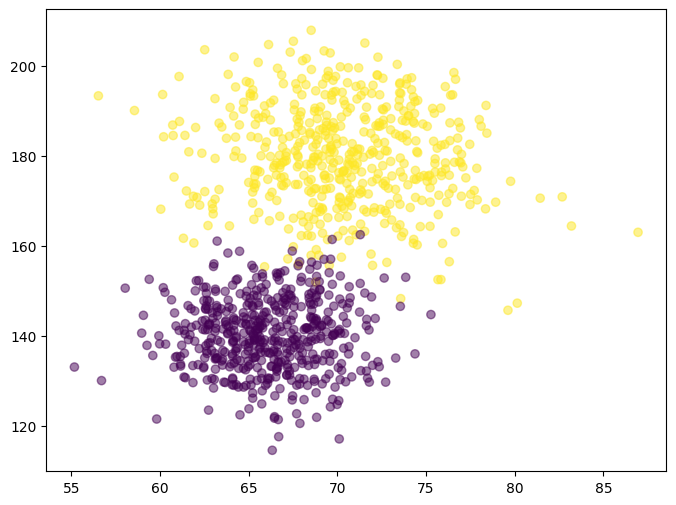

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y, alpha=.5)
plt.show()


## Naive Bayes' Classifier

In [8]:
from scipy.stats import multivariate_normal as mvn

In [9]:
class GaussNB():

    def fit(self, X, y, epsilon=1e-3):
        self.likelihoods = dict()
        self.priors = dict()
        self.K = set(y.astype(int))

        for k in self.K:
            X_k = X[y==k]
            self.likelihoods[k] = {'mean':X_k.mean(axis=0), 'cov':X_k.var(axis=0)+epsilon}
            self.priors[k] = len(X_k)/len(X)
    
    def predict(self, X):
        N, d = X.shape
        P_hat = np.zeros((N, len(self.K)))

        for k,l in self.likelihoods.items():
            P_hat[:,k] = mvn.logpdf(X, l['mean'], l['cov'] + np.log(self.priors[k]))
        
        return P_hat.argmax(axis=1)

In [10]:
def accuracy(y, y_hat):
    return np.mean(y==y_hat)

In [11]:
gnb = GaussNB()
gnb.fit(X,y)
y_hat = gnb.predict(X)
accuracy(y,y_hat)

np.float64(0.986)

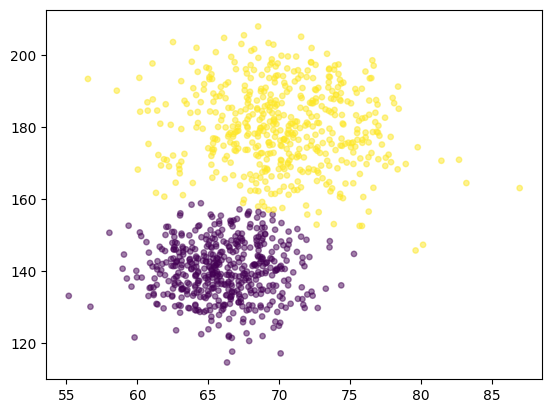

In [12]:
plt.figure()
plt.scatter(X[:,0],X[:,1], c=y_hat, alpha=.5, s=15)

In [13]:
data_xor = pd.read_csv('data/xor.csv')
X2 = data_xor.to_numpy()[:, :2]
y2 = data_xor.to_numpy()[:, 2]
y2


array([0., 0., 0., ..., 1., 1., 1.], shape=(4000,))

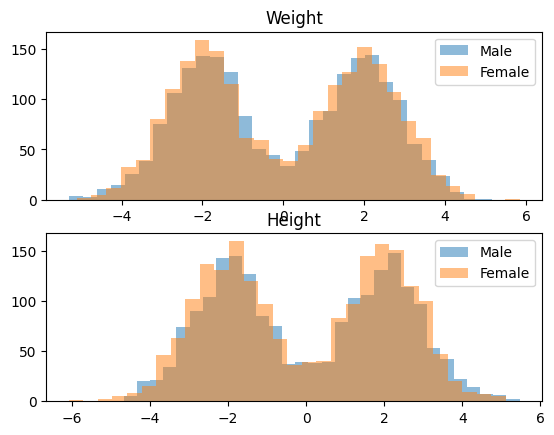

In [16]:
plt.figure()
plt.subplot(2,1,1)
plt.hist(X2[y2==1,0], label='Male', alpha=.5, bins=30)
plt.hist(X2[y2==0,0], label='Female', alpha=.5, bins=30)
plt.legend()
plt.title('Weight')
plt.subplot(2,1,2)
plt.hist(X2[y2==1,1], label='Male', alpha=.5, bins=30)
plt.hist(X2[y2==0,1], label='Female', alpha=.5, bins=30)
plt.legend()
plt.title('Height')
plt.show()

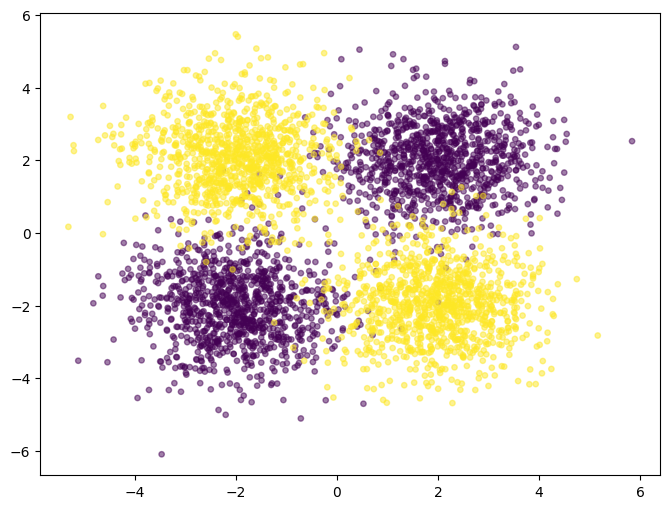

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(X2[:,0],X2[:,1],c=y2, alpha=.5, s=15)
plt.show()


In [18]:
gnb2 = GaussNB()
gnb2.fit(X2, y2)
y2_hat = gnb.predict(X2)
accuracy(y2,y2_hat)

np.float64(0.5)

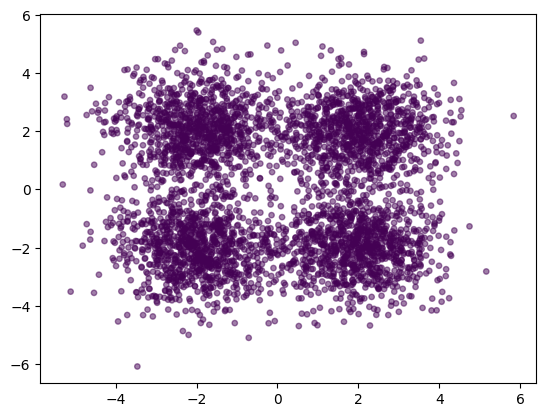

In [19]:
plt.scatter(X2[:,0],X2[:,1], c=y2_hat, alpha=.5, s=15)


In [23]:
gnb.priors
gnb.likelihoods

{np.int64(0): {'mean': array([ 66.07741984, 140.19334781]),
  'cov': array([ 9.11683513, 65.26096123])},
 np.int64(1): {'mean': array([ 70.23309181, 179.84174674]),
  'cov': array([ 18.24219346, 129.44756544])}}

## Non-Naive Bayes Classifier

In [56]:
class GaussBayes():

    def fit(self, X, y, epsilon=1e-3):
        self.params = {}
        self.priors = {}

        self.K = set(y.astype(int))
        
        for k in self.K:
            X_k = X[y==k,:]
            N_k, d = X_k.shape
            mu_k = X_k.mean(axis=0)
            cov_k = (1/(N_k-1)) * np.matmul((X_k-mu_k).T, (X_k-mu_k))+epsilon*np.identity(d)
            self.params[k] = {'mean':mu_k, 'cov':cov_k}
            self.priors[k] = len(X_k)/len(X)

    def predict(self, X):
        N, d = X.shape
        P_hat = np.zeros((N, len(self.K)))

        for k, l in self.params.items():
            P_hat[:,k] = mvn.logpdf(X, l['mean'], l['cov']) + np.log(self.priors[k])

        return P_hat.argmax(axis=1)


In [58]:
gb = GaussBayes()
gb.fit(X2, y2)
y2gb_hat = gb.predict(X2)
accuracy(y2, y2gb_hat)

np.float64(0.95825)

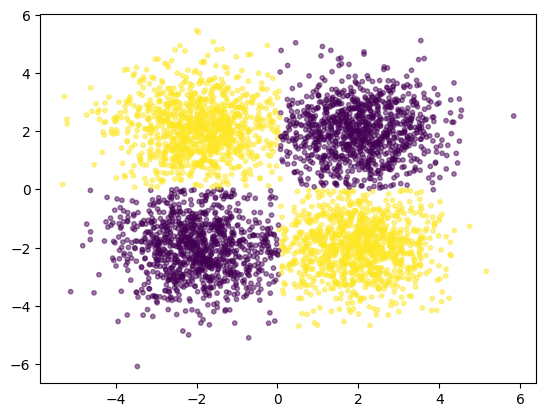

In [61]:

plt.figure()
plt.scatter(X2[:,0],X2[:,1],c=y2gb_hat, alpha=.5, s=10)